# ARI3129 - Data Visualization
TP

## Imports

In [1]:
from pycocotools.coco import COCO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Processing the Data
Annotation data was loaded from the COCO dataset as this allows for simpler manipulation through the pycocotools library. Additionally, to DataFrame will allow for efficient plotting using the seaborn module.

In [2]:
# NOTE: USES THE 3-SPLIT COCO DATASET(train, test, val) AND COMBINES TO 1 DF

def coco_to_df(path):
  coco = COCO(path)
  ann_ids = coco.getAnnIds()
  anns = coco.loadAnns(ann_ids)
  rows = []

  for ann in anns:
    category_id = ann['category_id']
    attrs = ann['attributes']

    row = {
        "sign_type": coco.loadCats(category_id)[0]['name'],
        "view_angle": attrs["view_angle"][0],
        "mounting": attrs["mounting"][0],
        "condition": attrs["condition"][0],
        "sign_shape": attrs["sign_shape"][0],
    }

    rows.append(row)

  return pd.DataFrame(rows)

## Joining the 3 Splits into 1 Dataframe

In [4]:
paths = ["train.json", "test.json", "val.json"]
signs = pd.concat([coco_to_df(path) for path in paths])

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [5]:
signs

,sign_type,view_angle,mounting,condition,sign_shape
0,No Entry (One Way),Front,Wall-mounted,Weathered,Circular
1,No Entry (One Way),Side,Wall-mounted,Weathered,Circular
2,No Entry (One Way),Back,Wall-mounted,Weathered,Circular
3,No Entry (One Way),Front,Pole-mounted,Weathered,Circular
4,No Entry (One Way),Side,Pole-mounted,Weathered,Circular
...,...,...,...,...,...
91,Stop,Front,Pole-mounted,Good,Octagonal
92,Blind-Spot Mirror (Convex),Front,Pole-mounted,Good,Circular
93,Blind-Spot Mirror (Convex),Side,Pole-mounted,Good,Circular
94,Stop,Front,Pole-mounted,Good,Octagonal


## Plotting Total Counts

/tmp/ipython-input-1354175423.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
/tmp/ipython-input-1354175423.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
/tmp/ipython-input-1354175423.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
/tmp/ipython-input-1354175423.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
/tmp/ipython-input-1354175423.py:11: UserWarning: set_ticklabels() s

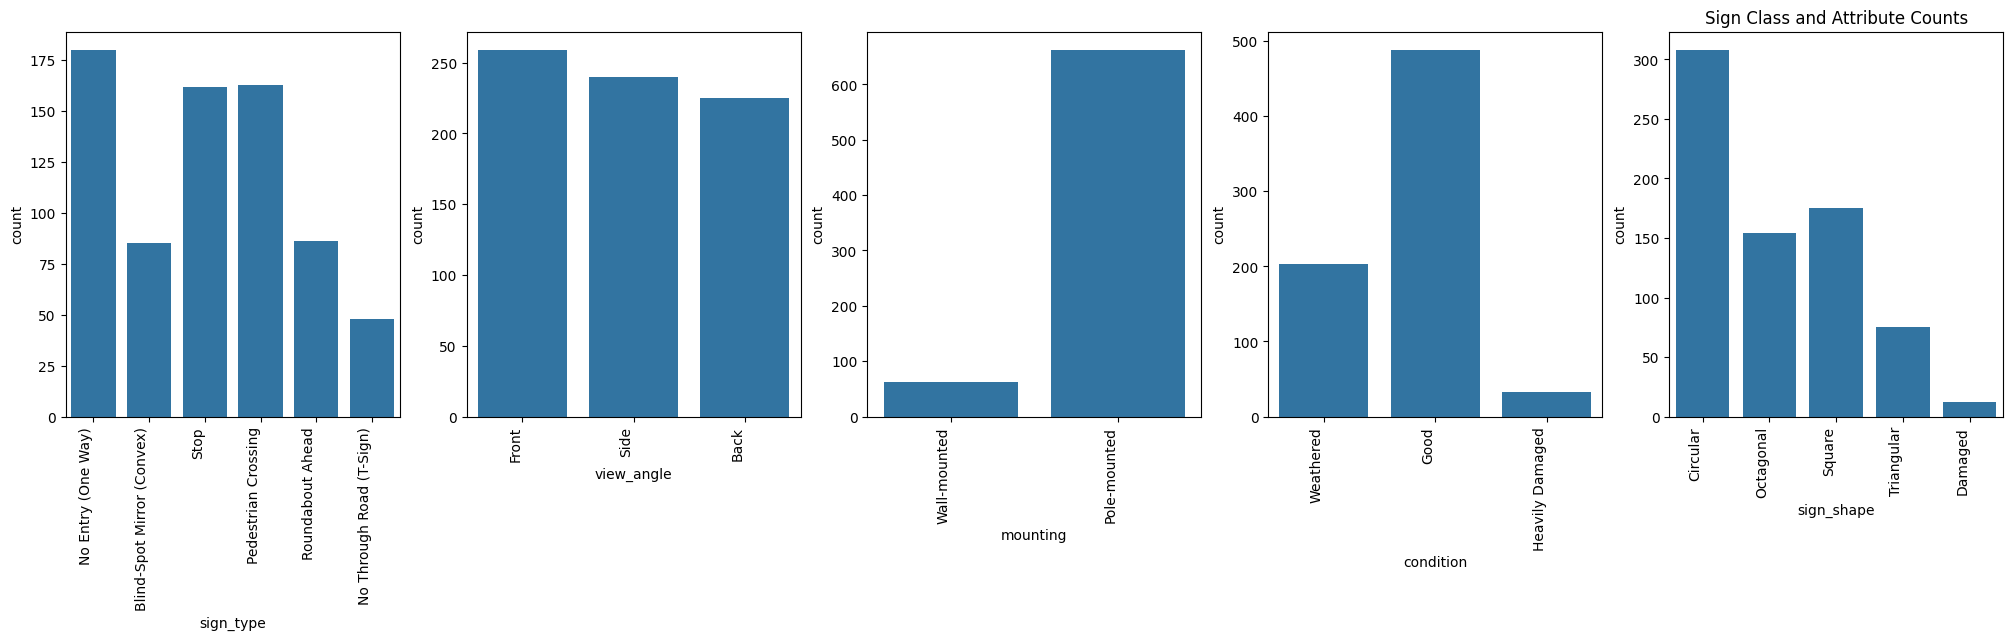

In [6]:
# PLOTTING TOTALS
fig, axs = plt.subplots(1, 5, figsize=(25, 5))
axs = axs.flatten()

labels = list(signs.columns)

for axid, label in enumerate(labels):
  sns.countplot(signs, x=label, width=0.8, ax=axs[axid])

for ax in axs:
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")

plt.title("Sign Class and Attribute Counts")
plt.show()




In [10]:
labels = list(signs.columns)
for label in labels:
  print("================")
  print(signs[label].value_counts())
  print()

sign_type
No Entry (One Way)            180
Pedestrian Crossing           163
Stop                          162
Roundabout Ahead               86
Blind-Spot Mirror (Convex)     85
No Through Road (T-Sign)       48
Name: count, dtype: int64

view_angle
Front    259
Side     240
Back     225
Name: count, dtype: int64

mounting
Pole-mounted    662
Wall-mounted     62
Name: count, dtype: int64

condition
Good               488
Weathered          203
Heavily Damaged     33
Name: count, dtype: int64

sign_shape
Circular      308
Square        175
Octagonal     154
Triangular     75
Damaged        12
Name: count, dtype: int64



## Plotting by Attribute

/tmp/ipython-input-3348696445.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
/tmp/ipython-input-3348696445.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
/tmp/ipython-input-3348696445.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
/tmp/ipython-input-3348696445.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")


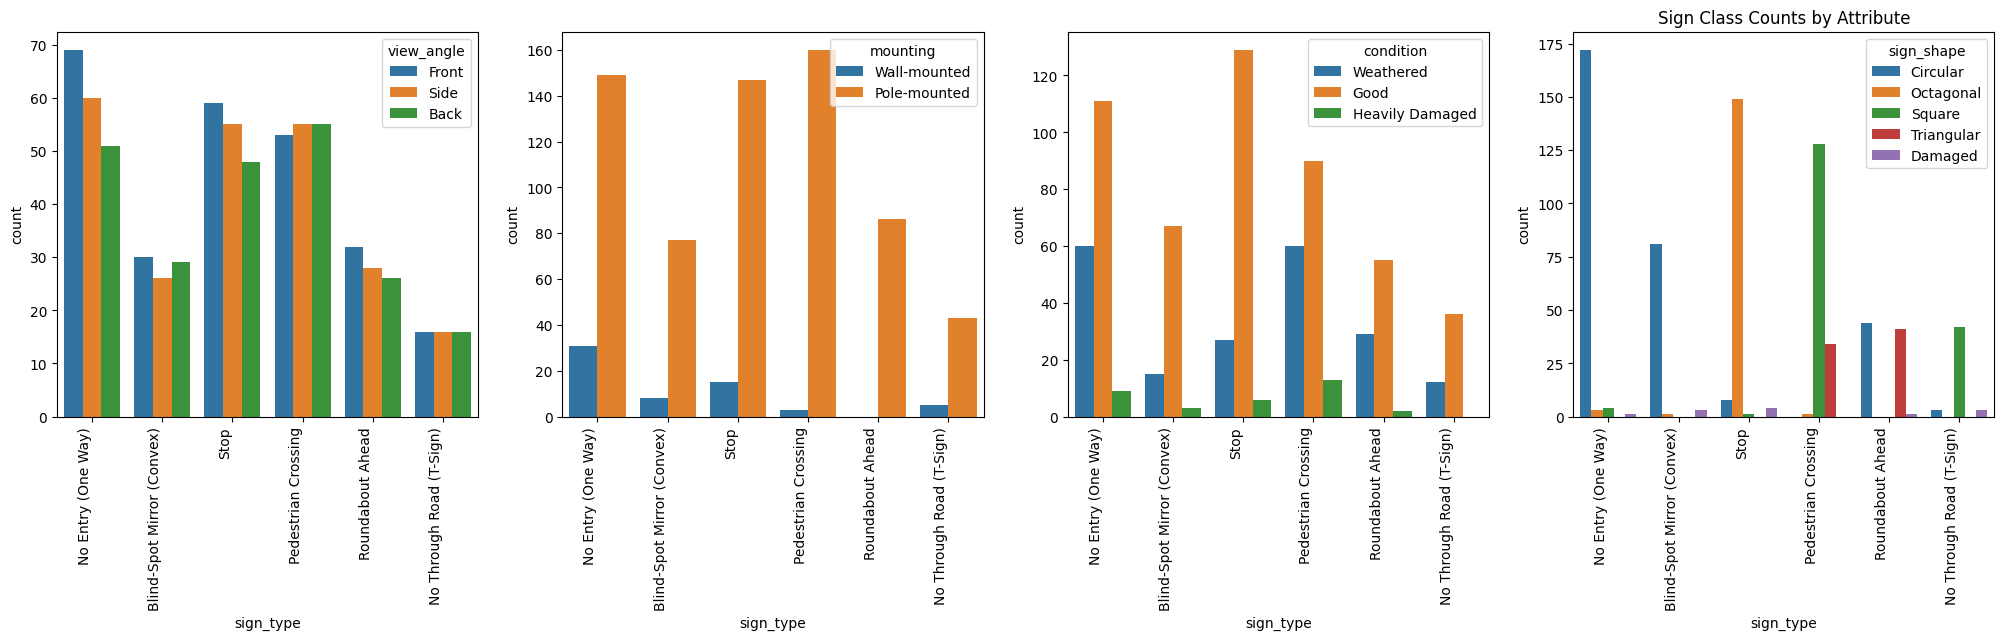

In [7]:
# PLOTTING
fig, axs = plt.subplots(1, 4, figsize=(25, 5))
axs = axs.flatten()

labels = list(signs.columns)

for axid, label in enumerate(labels[1:]):
  sns.countplot(signs, x="sign_type", hue=label, width=0.8, ax=axs[axid])

for ax in axs:
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")

plt.title("Sign Class Counts by Attribute")
plt.show()


